In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Demarrage - Ctrl+C pour arreter

22:00:41
  Bitcoin  : $64,054.00  (-0.80%)
  Ethereum : $1,854.11  (-0.50%)
  Sauvegarde effectuee


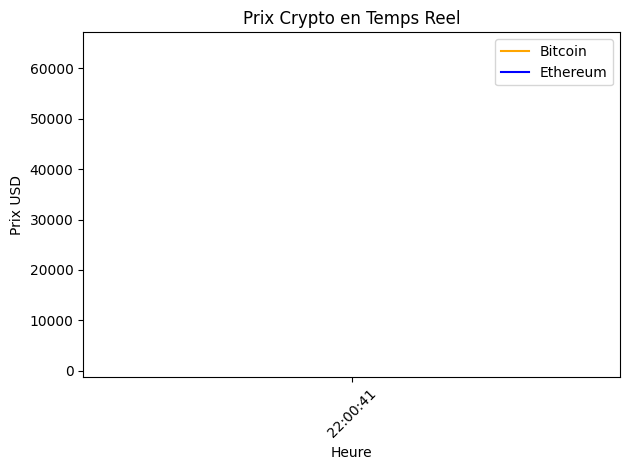

  Prochaine collecte dans 30s...

22:01:12
  Bitcoin  : $64,054.00  (-0.80%)
  Ethereum : $1,854.11  (-0.50%)
  Sauvegarde effectuee


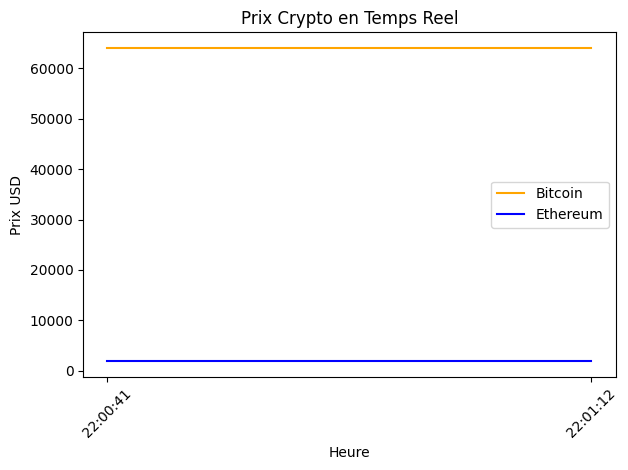

  Prochaine collecte dans 30s...

22:01:43
  Bitcoin  : $64,031.00  (-1.10%)
  Ethereum : $1,853.79  (-0.52%)
  Sauvegarde effectuee


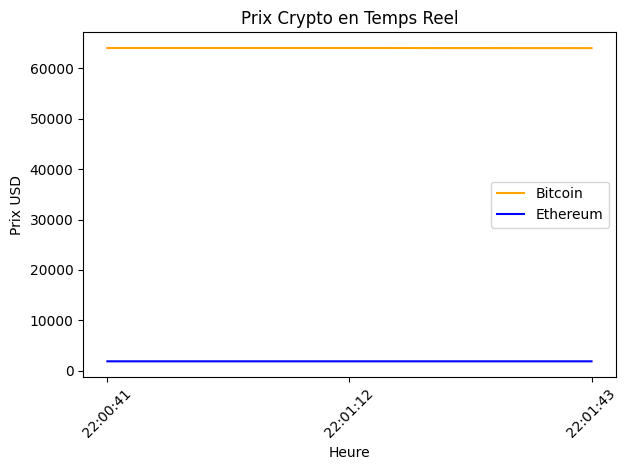

  Prochaine collecte dans 30s...

22:02:14
  Bitcoin  : $64,031.00  (-1.10%)
  Ethereum : $1,853.79  (-0.52%)
  Sauvegarde effectuee


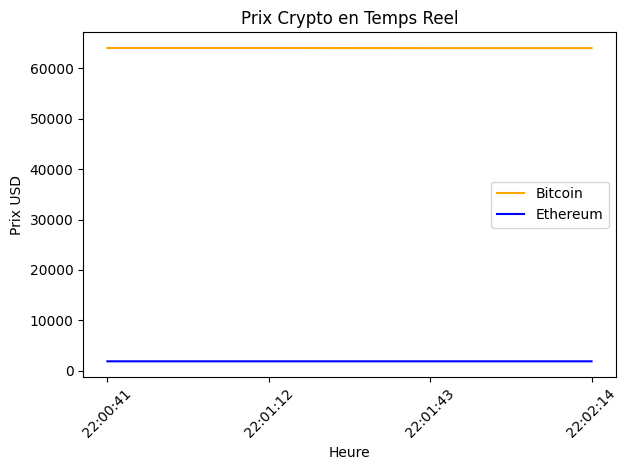

  Prochaine collecte dans 30s...

22:02:45
  Bitcoin  : $64,013.00  (-1.13%)
  Ethereum : $1,853.65  (-0.53%)
  Sauvegarde effectuee


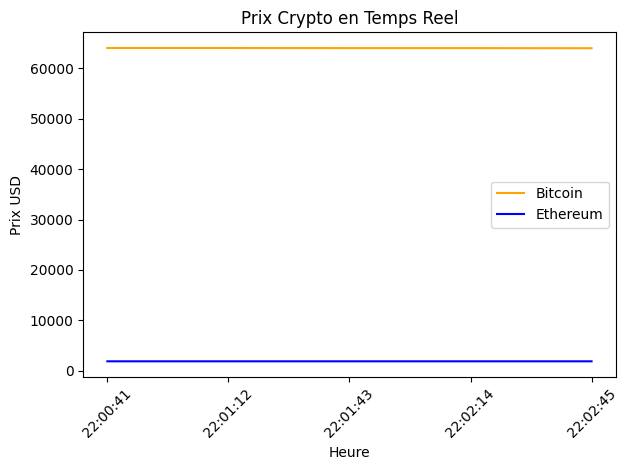

  Prochaine collecte dans 30s...


In [ ]:
# Analyse Crypto en Temps Reel - CoinGecko

import requests
import csv
import time
from datetime import datetime
import matplotlib.pyplot as plt

# ================================
# CONFIGURATION
# ================================

INTERVALLE = 30       # secondes entre chaque collecte
FICHIER    = "crypto_data.csv"

historique_temps    = []
historique_bitcoin  = []
historique_ethereum = []

# Creer le fichier CSV avec l'en-tete
with open(FICHIER, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["heure", "bitcoin", "ethereum"])

print("Demarrage - Ctrl+C pour arreter")

# ================================
# BOUCLE PRINCIPALE
# ================================

while True:

    # Appel API
    url     = "https://api.coingecko.com/api/v3/simple/price?ids=bitcoin,ethereum&vs_currencies=usd&include_24hr_change=true"
    reponse = requests.get(url, timeout=10)
    donnees = reponse.json()

    heure   = datetime.now().strftime("%H:%M:%S")
    btc     = donnees["bitcoin"]["usd"]
    eth     = donnees["ethereum"]["usd"]
    btc_var = donnees["bitcoin"]["usd_24h_change"]
    eth_var = donnees["ethereum"]["usd_24h_change"]

    # Affichage console
    print(f"\n{heure}")
    print(f"  Bitcoin  : ${btc:,.2f}  ({btc_var:+.2f}%)")
    print(f"  Ethereum : ${eth:,.2f}  ({eth_var:+.2f}%)")

    # Sauvegarde CSV
    with open(FICHIER, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([heure, btc, eth])
    print(f"  Sauvegarde effectuee")

    # Ajout dans l'historique
    historique_temps.append(heure)
    historique_bitcoin.append(btc)
    historique_ethereum.append(eth)

    # Garder seulement les 20 derniers points
    if len(historique_temps) > 20:
        historique_temps.pop(0)
        historique_bitcoin.pop(0)
        historique_ethereum.pop(0)

    # Graphique
    plt.clf()
    plt.plot(historique_temps, historique_bitcoin,  label="Bitcoin",  color="orange")
    plt.plot(historique_temps, historique_ethereum, label="Ethereum", color="blue")
    plt.title("Prix Crypto en Temps Reel")
    plt.xlabel("Heure")
    plt.ylabel("Prix USD")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.pause(0.1)

    # Attente avant prochaine collecte
    print(f"  Prochaine collecte dans {INTERVALLE}s...")
    time.sleep(INTERVALLE)